In [62]:
import pandas as pd
import matplotlib.pyplot as plt
import japanize_matplotlib

df = pd.read_csv(r'C:\Users\nobu2\auto-data-analysis\hotel\archive\hotel_bookings.csv')
df.head()


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


データの全体像を把握する

In [63]:
print(df.shape)
print(df['is_canceled'].value_counts())
print(df['is_canceled'].mean())


(119390, 32)
is_canceled
0    75166
1    44224
Name: count, dtype: int64
0.37041628277075134


In [64]:
print(df.isnull().sum().sort_values(ascending=False).head(10))
print(df.dtypes.value_counts())


company                      112593
agent                         16340
country                         488
children                          4
arrival_date_month                0
arrival_date_week_number          0
hotel                             0
is_canceled                       0
stays_in_weekend_nights           0
arrival_date_day_of_month         0
dtype: int64
int64      16
str        12
float64     4
Name: count, dtype: int64


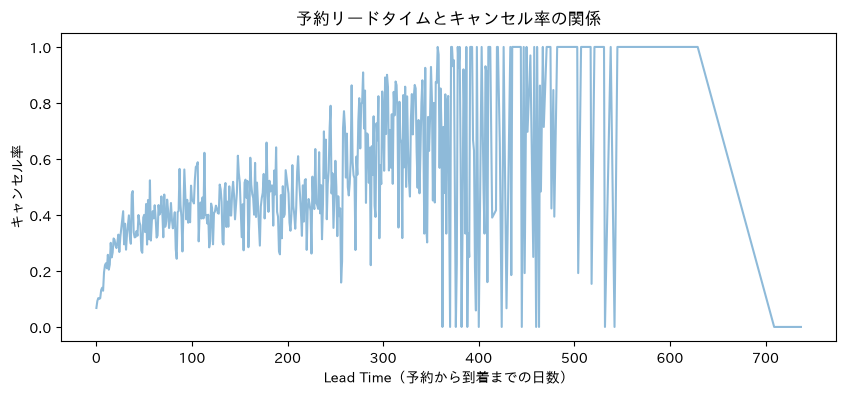

In [65]:
import matplotlib.pyplot as plt
import japanize_matplotlib

cancel_rate = df.groupby('lead_time')['is_canceled'].mean()

plt.figure(figsize=(10, 4))
plt.plot(cancel_rate.index, cancel_rate.values, alpha=0.5)
plt.xlabel('Lead Time（予約から到着までの日数）')
plt.ylabel('キャンセル率')
plt.title('予約リードタイムとキャンセル率の関係')
plt.show()


In [66]:
print(df.columns.tolist())


['hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'assigned_room_type', 'booking_changes', 'deposit_type', 'agent', 'company', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'reservation_status', 'reservation_status_date']


In [67]:
print(df['previous_cancellations'].value_counts().sort_index())
print(f'\n最大値: {df["previous_cancellations"].max()}')
print(f'0の割合: {(df["previous_cancellations"] == 0).mean():.1%}')


previous_cancellations
0     112906
1       6051
2        116
3         65
4         31
5         19
6         22
11        35
13        12
14        14
19        19
21         1
24        48
25        25
26        26
Name: count, dtype: int64

最大値: 26
0の割合: 94.6%


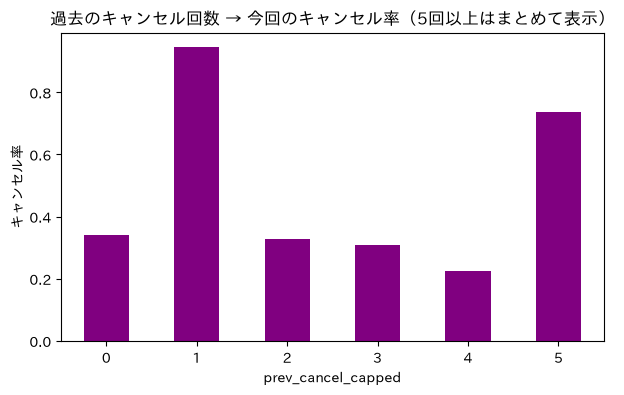

In [68]:
df['prev_cancel_capped'] = df['previous_cancellations'].clip(upper=5)

df.groupby('prev_cancel_capped')['is_canceled'].mean().plot(
    kind='bar', figsize=(7, 4), color='purple'
)
plt.ylabel('キャンセル率')
plt.title('過去のキャンセル回数 → 今回のキャンセル率（5回以上はまとめて表示）')
plt.xticks(rotation=0)
plt.show()


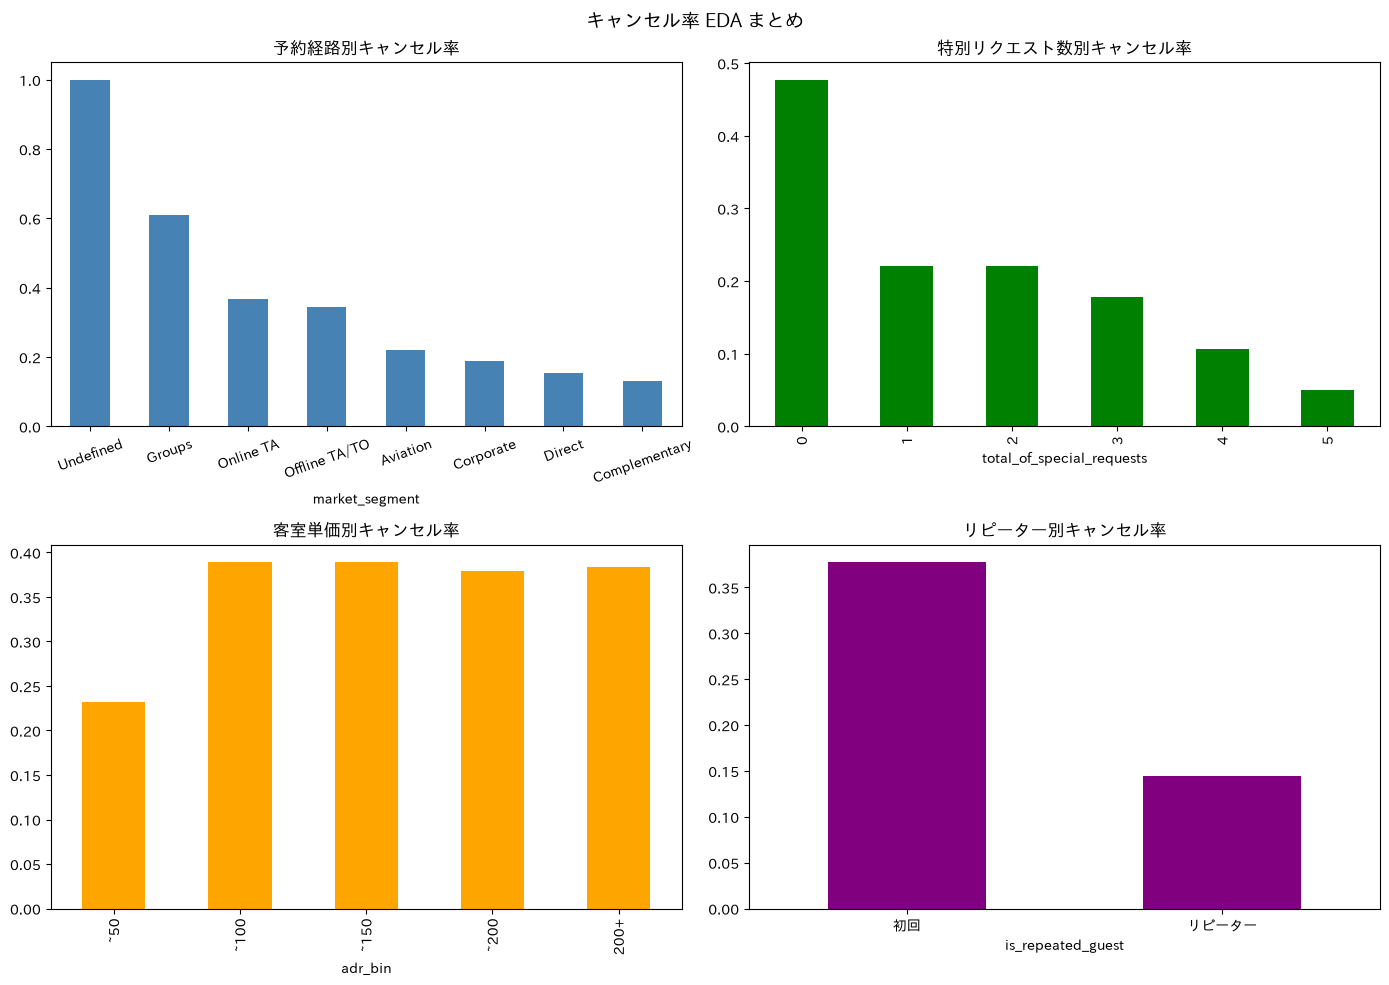

In [69]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ① 予約経路
df.groupby('market_segment')['is_canceled'].mean().sort_values(ascending=False).plot(
    kind='bar', ax=axes[0][0], color='steelblue'
)
axes[0][0].set_title('予約経路別キャンセル率')
axes[0][0].tick_params(axis='x', rotation=20)

# ② 特別リクエスト数
df.groupby('total_of_special_requests')['is_canceled'].mean().plot(
    kind='bar', ax=axes[0][1], color='green'
)
axes[0][1].set_title('特別リクエスト数別キャンセル率')

# ③ 客室単価（adr）を区間に分けて
df['adr_bin'] = pd.cut(df['adr'], bins=[0, 50, 100, 150, 200, 500], labels=['~50','~100','~150','~200','200+'])
df.groupby('adr_bin', observed=True)['is_canceled'].mean().plot(
    kind='bar', ax=axes[1][0], color='orange'
)
axes[1][0].set_title('客室単価別キャンセル率')

# ④ リピーター
df.groupby('is_repeated_guest')['is_canceled'].mean().plot(
    kind='bar', ax=axes[1][1], color='purple'
)
axes[1][1].set_title('リピーター別キャンセル率')
axes[1][1].set_xticklabels(['初回', 'リピーター'], rotation=0)

plt.suptitle('キャンセル率 EDA まとめ', fontsize=14)
plt.tight_layout()
plt.show()


In [70]:
print(df['country'].value_counts().head(15))

country
PRT    48590
GBR    12129
FRA    10415
ESP     8568
DEU     7287
ITA     3766
IRL     3375
BEL     2342
BRA     2224
NLD     2104
USA     2097
CHE     1730
CN      1279
AUT     1263
SWE     1024
Name: count, dtype: int64


In [71]:
print(df['hotel'].value_counts())


hotel
City Hotel      79330
Resort Hotel    40060
Name: count, dtype: int64


In [72]:
df2 = df.copy()

# リーク列を削除
df2 = df2.drop(['reservation_status', 'reservation_status_date'], axis=1)

# 欠損値処理
df2['children'] = df2['children'].fillna(0)
df2['country'] = df2['country'].fillna('Unknown')
df2['agent'] = df2['agent'].fillna(0)
df2 = df2.drop('company', axis=1)

# 月を数値に変換
month_map = {'January':1,'February':2,'March':3,'April':4,'May':5,'June':6,
             'July':7,'August':8,'September':9,'October':10,'November':11,'December':12}
df2['arrival_date_month'] = df2['arrival_date_month'].map(month_map)

# 文字列列をダミー変数に変換
cat_cols = ['hotel','meal','market_segment','distribution_channel',
            'reserved_room_type','assigned_room_type','deposit_type','customer_type']
df2 = pd.get_dummies(df2, columns=cat_cols, drop_first=True)

# countryは上位10カ国+Otherに集約
top10 = df['country'].value_counts().head(10).index
df2['country'] = df2['country'].apply(lambda x: x if x in top10 else 'Other')
df2 = pd.get_dummies(df2, columns=['country'], drop_first=True)

print(df2.shape)
print(df2.isnull().sum().sum())


(119390, 73)
1963


In [73]:
print(df.select_dtypes(include='object').columns.tolist())


['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type', 'reservation_status', 'reservation_status_date']


C:\Users\nobu2\AppData\Local\Temp\ipykernel_13136\330033671.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df.select_dtypes(include='object').columns.tolist())


In [74]:
for col in df.select_dtypes(include='object').columns:
    print(col)


hotel
arrival_date_month
meal
country
market_segment
distribution_channel
reserved_room_type
assigned_room_type
deposit_type
customer_type
reservation_status
reservation_status_date


C:\Users\nobu2\AppData\Local\Temp\ipykernel_13136\947207321.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


In [75]:
for col in df.select_dtypes(include='str').columns:
    print(col)

hotel
arrival_date_month
meal
country
market_segment
distribution_channel
reserved_room_type
assigned_room_type
deposit_type
customer_type
reservation_status
reservation_status_date


In [76]:
df.dtypes


hotel                                  str
is_canceled                          int64
lead_time                            int64
arrival_date_year                    int64
arrival_date_month                     str
arrival_date_week_number             int64
arrival_date_day_of_month            int64
stays_in_weekend_nights              int64
stays_in_week_nights                 int64
adults                               int64
children                           float64
babies                               int64
meal                                   str
country                                str
market_segment                         str
distribution_channel                   str
is_repeated_guest                    int64
previous_cancellations               int64
previous_bookings_not_canceled       int64
reserved_room_type                     str
assigned_room_type                     str
booking_changes                      int64
deposit_type                           str
agent      

In [77]:
print(df.dtypes.to_string())


hotel                                  str
is_canceled                          int64
lead_time                            int64
arrival_date_year                    int64
arrival_date_month                     str
arrival_date_week_number             int64
arrival_date_day_of_month            int64
stays_in_weekend_nights              int64
stays_in_week_nights                 int64
adults                               int64
children                           float64
babies                               int64
meal                                   str
country                                str
market_segment                         str
distribution_channel                   str
is_repeated_guest                    int64
previous_cancellations               int64
previous_bookings_not_canceled       int64
reserved_room_type                     str
assigned_room_type                     str
booking_changes                      int64
deposit_type                           str
agent      

In [78]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 34 columns):
 #   Column                          Non-Null Count   Dtype   
---  ------                          --------------   -----   
 0   hotel                           119390 non-null  str     
 1   is_canceled                     119390 non-null  int64   
 2   lead_time                       119390 non-null  int64   
 3   arrival_date_year               119390 non-null  int64   
 4   arrival_date_month              119390 non-null  str     
 5   arrival_date_week_number        119390 non-null  int64   
 6   arrival_date_day_of_month       119390 non-null  int64   
 7   stays_in_weekend_nights         119390 non-null  int64   
 8   stays_in_week_nights            119390 non-null  int64   
 9   adults                          119390 non-null  int64   
 10  children                        119386 non-null  float64 
 11  babies                          119390 non-null  int64   
 12  meal         

In [79]:
print(df2.select_dtypes(include='str').columns.tolist())


[]


In [80]:
print(df2.select_dtypes(include='str').columns.tolist())

[]


In [81]:
print(df2.select_dtypes(include='category').columns.tolist())


['adr_bin']


In [82]:
df2 = df2.drop('adr_bin', axis=1)


In [83]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

X = df2.drop('is_canceled', axis=1)
y = df2['is_canceled']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
print(f'AUC: {roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]):.4f}')
print(classification_report(y_test, y_pred))

    

AUC: 0.9593
              precision    recall  f1-score   support

           0       0.90      0.94      0.92     15033
           1       0.89      0.82      0.85      8845

    accuracy                           0.89     23878
   macro avg       0.89      0.88      0.88     23878
weighted avg       0.89      0.89      0.89     23878



In [84]:
print(df2.isnull().sum()[df2.isnull().sum() > 0])

Series([], dtype: int64)


In [85]:
proba = rf.predict_proba(X_test)[:, 1]
pred = rf.predict(X_test)

print('確率:', proba[:5])
print('予測:', pred[:5])


確率: [0.09513095 0.03       0.92333333 0.1        0.        ]
予測: [0 0 1 0 0]


In [86]:
import pandas as pd

result = pd.DataFrame({
    'キャンセル確率': proba[:10].round(3),
    '予測': pred[:10],
    '実際': y_test.values[:10]
})
print(result)

   キャンセル確率  予測  実際
0    0.095   0   0
1    0.030   0   0
2    0.923   1   1
3    0.100   0   0
4    0.000   0   0
5    1.000   1   1
6    1.000   1   1
7    0.840   1   0
8    0.220   0   0
9    0.000   0   0


In [87]:
# リーク列が混入していないか確認
print(X.columns.tolist())


['lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'prev_cancel_capped', 'hotel_Resort Hotel', 'meal_FB', 'meal_HB', 'meal_SC', 'meal_Undefined', 'market_segment_Complementary', 'market_segment_Corporate', 'market_segment_Direct', 'market_segment_Groups', 'market_segment_Offline TA/TO', 'market_segment_Online TA', 'market_segment_Undefined', 'distribution_channel_Direct', 'distribution_channel_GDS', 'distribution_channel_TA/TO', 'distribution_channel_Undefined', 'reserved_room_type_B', 'reserved_room_type_C', 'reserved_room_type_D', 'reserved_room_type_E', 'reserved_room_type_F', 'reserved_room_type_G', 'reserved_room_type_H', 'reserved_room_type